# D1 Fundamentals and dimensional analysis

## Introduction

The main characteristics of turbomachinery has been already introduced in previous courses of the Batchelor Degree and Master. In this course we explore in 
detail the design of a specific type on hydraulic turbomachine: **the axial fan**

In this first notebook we go over some basic concepts already covered in previous subjects.

## Learning objectives
1. Define the concept of _Hydraulic Turbomachine_
2. Enumerate different kinds of hydraulic turbomachines with the main characteristics
3. Explain the concept of absolute and relative velocities and angles
4. Relate _stagnation_ (or _total_) _enthalpy_ to energy transfer
5. Apply the moment of momentum balance to get the **Euler equation**
6. Define _rothalpy_
7. Define **efficiency** for an axial fan
8. Define **flow and head coefficient**
9. Define specific **speed and specific diameter**
10. Classify turbomachines in function of the **dimensionless parameters**
11. Use the **Cordier diagram** to locate the operation point of a turbomachine

## Previous tasks (about 2.5 hours)

Read part of chapters 1 and 2 of the book by Dixon


  DIXON, S.L. (Sydney L. y HALL, C.A., 2010. Fluid Mechanics and Thermodynamics of Turbomachinery (6th Edition). 6th Edition. Oxford: Elsevier. ISBN 1856177939. 

that is [available on the UPC library](https://discovery.upc.edu/permalink/34CSUC_UPC/12g8t5d/cdi_nii_cinii_1970023484961124628)

Don't read the whole chapters. Avoid the parts about compressible flow that will not be used in the present course. Specifically, read the sections:
- 1.1 to 1.8
- 1.10 (the part about hydraulic machines)
- 2.1 to 2.3
- 2.6

## Some simple questions

What is the main difference between a **driven turbomachine** (Power-absorving) and a **driving turbomachine** (Power-Generating)? Give some examples of both types. How is that related to the **Euler Equation**?

Answer


***

Explain with your words what is the _rothalpy_. Why is that conserved in a rotor?



Answer

Rothalpy is the same as enthalpy of stagnation, that describes the total fluid energy for ideal fluid (adiabatic, irreversible and steady), but in the case of enthalpy of stagnation it refers to an observer on the ground, in contrast, with rothalpy the observer is seated on a moving turbine blade.
Rothalpy is conserved at rotor, because we are talking about ideal rotor, we are seated on the blades, so the relative velocity is cero, there is no work to the fluid.  By the first law of thermodynamic total energy need to be conserved at straight streamline. Depending on Radius enthalpy of stagnation term and centrifuged forces will be inverse (augmenting and decreasing) his magnitudes, so it will remain rothalpy constant. It won’t happen in stator, because there will be relative velocities and will appear mechanical forces.

***

This is an scheme of the triangle of velocities in the outlet of an axial fan

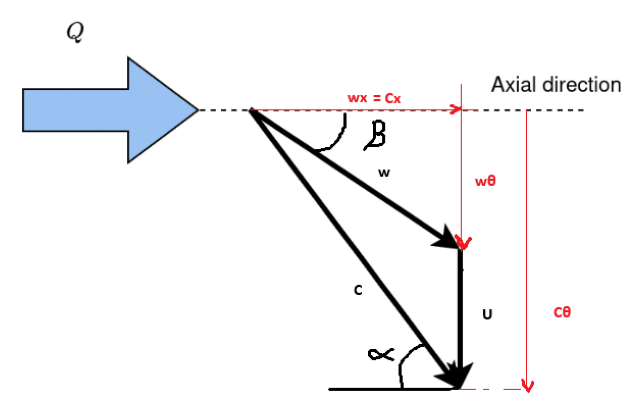

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# The image
img = mpimg.imread('images/D1_velocities_triangle.png')

# Size of the image
plt.figure(figsize=(8, 6))  # 8 pulgadas de ancho, 6 de alto
plt.imshow(img)
plt.axis('off')  # Without axes
plt.show()

- Locate the **blade velocity** $\mathbf{U}\, (=\mathbf{\omega}\times\mathbf{r})$
- Locate the **absolute velocity** $\mathbf{c}$ and its components $c_\theta$ and $c_x$
- Locate the **relative velocity** $\mathbf{w}$ and its components $w_\theta$ and $w_x$
- Locate **absolute angle** $\alpha$ and **relative angle** $\beta$

Hint: you can use the online app [draw.oi](https://draw.io), copy and paste this diagram, put the answer, export and overwrite the
 `images/D1_velocities_triangle.png` file and run the previous cell. Other option is just draw in by hand or in a tablet and make a picture.

Answer

***

## Tasks

These are the main characteristic of the axial fan [TXBR-250 ECOWATT by Soler & Palay](https://www.solerpalau.com/en-en/1634-txbr-ecowatt):

![S&P](images/D1_SP_TXBR-ECOWATT.png)

- Flow rate: $Q = 1617 \; \text{m}^3/\text{h}$
- Rotational speed: $N = 2275 \; \text{rpm}$
- Diameter $D = 250 \; \text{mm}$
- Hub diameter $D_h = 64 \;\text{mm}$
- Consumed power $P = 131\;\text{W}$
- Blade angle in outlet (_trailing edge_): $\beta_2 = 50^\circ$

Questions:

- Compute mean radius. It can be done with average radius, $r_m = \frac{1}{2}\left(r_h + r_t\right)$, or with the RMS, that is more accurate and it will be used later for the 3D analysis, $r_m = \sqrt{\frac{1}{2}\left(r_h^2 + r_t^2\right)}$
- Compute the **blade velocity** $U$
- Compute average **axial velocity** of air in inlet, $c_{x,1}$ and consider it as the axial velocity in the mean radius.
- Inlet flow is axial. Compute the **blade angle in inlet** (_leading edge_) $\beta_1$
- Compute tangential components of **absolute velocity** in the leading and the trailing edges ($c_{\theta1}$ and $c_{\theta2}$)
- Draw the **triangles of velocities** in leading and trailing edges
- Apply **Euler equation** to estimate head pressure of the fan. Express it in Pa, bar and mmH2O
- Estimate the **efficiency** the fan

In [11]:
# TODO: Compute velocities and angles, and draw the triangles of velocities. Apply Euler equation to estimate head pressure. Compute efficiency.
import numpy as np
# Input data
Q_m3h = 1617.0             # m3/h
N_rpm = 2275.0             # rpm
D_t = 0.250                # m
D_h = 0.064                # m
P_elec = 131.0             # W
beta2_deg = 50.0           # deg (trailing edge relative angle)
rho = 1.2                  # kg/m3

# Unit conversions
Q = Q_m3h / 3600.0         # m3/s
omega = N_rpm * 2 * np.pi / 60.0 # rad/s
r_t = D_t / 2.0
r_h = D_h / 2.0

# 1. Mean Radius (RMS)
r_m_avg = (r_h + r_t) / 2.0
r_m = np.sqrt(0.5 * (r_h**2 + r_t**2))

# 2. Blade velocity U
U = omega * r_m

# 3. Axial velocity c_x
A_annulus = np.pi * (r_t**2 - r_h**2)
c_x = Q / A_annulus

# 4. Leading edge inlet relative angle beta1 (purely axial inlet)
beta1_rad = np.arctan(U / c_x)
beta1_deg = np.degrees(beta1_rad)

# 5. Tangential components of absolute velocity
c_theta1 = 0.0
w_theta2 = c_x * np.tan(np.radians(beta2_deg))
c_theta2 = U - w_theta2

# 6. Euler head pressure
delta_w = U * c_theta2
delta_p0_Pa = rho * delta_w
delta_p0_bar = delta_p0_Pa / 1e5
delta_p0_mmH2O = delta_p0_Pa / 9.80665

# 7. Efficiency
P_fluid = Q * delta_p0_Pa
eta = P_fluid / P_elec

from tabulate import tabulate

# Display results
print(f"Mean Radius (RMS): {r_m:.5f} m (Average method: {r_m_avg:.5f} m)")
print(f"Blade Velocity U: {U:.3f} m/s")
print(f"Axial Velocity c_x: {c_x:.3f} m/s")
print(f"Inlet Blade Angle beta1: {beta1_deg:.2f}°")
print(f"Tangential Absolute Velocity c_theta1: {c_theta1:.3f} m/s")
print(f"Tangential Absolute Velocity c_theta2: {c_theta2:.3f} m/s")
print(f"Euler Head Pressure: {delta_p0_Pa:.2f} Pa | {delta_p0_bar:.6f} bar | {delta_p0_mmH2O:.2f} mmH2O")
print(f"Estimated Efficiency: {eta*100:.2f}%")

headers = ["Parameter", "Value", "Unit"]
table_data = [
    ["Mean Radius (RMS)", r_m, "m"],
    ["Blade Speed (U)", U, "m/s"],
    ["Axial Velocity (c_x)", c_x, "m/s"],
    ["Inlet Angle (β₁)", beta1_deg, "°"],
    ["Euler Pressure (Δp₀)", delta_p0_Pa, "Pa"],
    ["Total Efficiency (η)", eta*100, "%"]
]

# Print using fancy borders and rounded floats
print(tabulate(table_data, headers=headers, tablefmt="fancy_grid", floatfmt=".3f"))

Mean Radius (RMS): 0.09124 m (Average method: 0.07850 m)
Blade Velocity U: 21.736 m/s
Axial Velocity c_x: 9.792 m/s
Inlet Blade Angle beta1: 65.75°
Tangential Absolute Velocity c_theta1: 0.000 m/s
Tangential Absolute Velocity c_theta2: 10.067 m/s
Euler Head Pressure: 262.58 Pa | 0.002626 bar | 26.78 mmH2O
Estimated Efficiency: 90.03%
╒══════════════════════╤═════════╤════════╕
│ Parameter            │   Value │ Unit   │
╞══════════════════════╪═════════╪════════╡
│ Mean Radius (RMS)    │   0.091 │ m      │
├──────────────────────┼─────────┼────────┤
│ Blade Speed (U)      │  21.736 │ m/s    │
├──────────────────────┼─────────┼────────┤
│ Axial Velocity (c_x) │   9.792 │ m/s    │
├──────────────────────┼─────────┼────────┤
│ Inlet Angle (β₁)     │  65.749 │ °      │
├──────────────────────┼─────────┼────────┤
│ Euler Pressure (Δp₀) │ 262.578 │ Pa     │
├──────────────────────┼─────────┼────────┤
│ Total Efficiency (η) │  90.032 │ %      │
╘══════════════════════╧═════════╧════════╛


For the previous fan, compute: 
- flow, head and power coefficients
$$ \phi = \frac{Q}{\omega D^3}$$
$$ \psi = \frac{\Delta p_0}{\rho \omega^2 D^2}$$
$$ \hat{P} = \frac{P_h}{\rho \omega^3 D^5} = \phi \psi$$
- Reynolds number
$$ \text{Re}_D = \frac{\rho c_m D}{\mu} $$
- Specific velocity and diameter
$$ D_s = \frac{D(\frac{\Delta p_0}{\rho})^{1/4}}{Q^{1/2}} $$
$$ \Omega_s = \frac{\Omega Q^{1/2}}{(\frac{\Delta p_0}{\rho})^{3/4}} $$
- Locate the fan into the Cordier diagram 

     DIMENSIONLESS PARAMETERS & CORDIER DATA
Flow Coefficient (phi)        : 0.1207
Head Coefficient (psi)        : 0.0617
Power Coefficient (P_hat)     : 0.00744
Reynolds Number (Re_D)        : 1.62e+05
Specific Speed (Omega_s)      : 2.806
Specific Diameter (D_s)       : 1.435


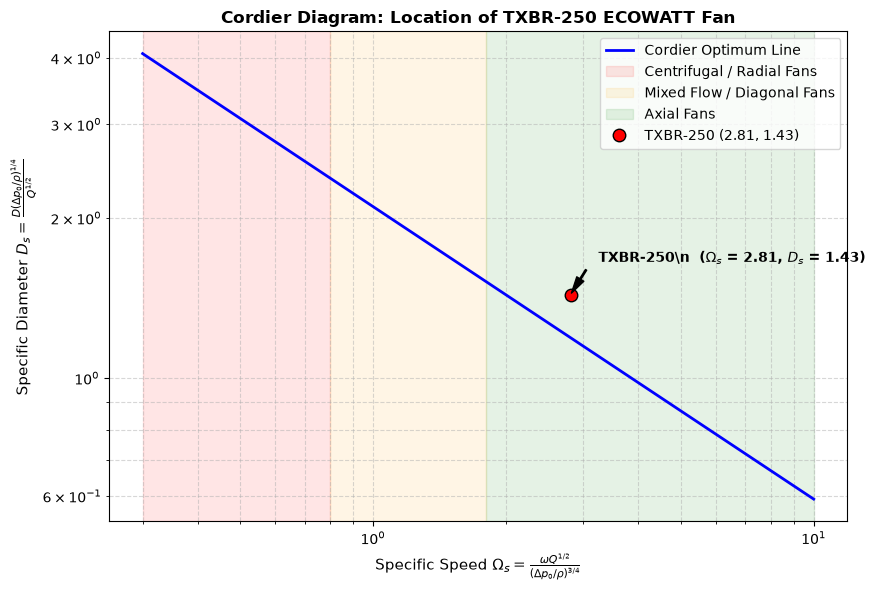

In [15]:
# TODO: Compute dimnesionless parameters. Locate in the Cordier diagram.
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. INPUT PARAMETERS & SI CONVERSIONS
# ==========================================
Q_m3h = 1617.0            # Volumetric flow rate [m³/h]
N_rpm = 2275.0            # Rotational speed [rpm]
D = 0.250                 # Casing/Tip diameter [m]
rho = 1.2                 # Air density [kg/m³]
mu = 1.81e-5              # Air dynamic viscosity [Pa·s] at 20°C
delta_p0 = 262.59         # Total head pressure rise [Pa]
c_m = 9.792               # Axial velocity [m/s]

# SI Unit Conversions
Q = Q_m3h / 3600.0                   # Flow rate [m³/s]
omega = N_rpm * (2.0 * np.pi / 60.0) # Angular velocity [rad/s]
P_h = Q * delta_p0                   # Hydraulic fluid power [W]

# ==========================================
# 2. DIMENSIONLESS PARAMETERS
# ==========================================
# Flow Coefficient
phi = Q / (omega * D**3)

# Head / Loading Coefficient
psi = delta_p0 / (rho * (omega**2) * (D**2))

# Power Coefficient
P_hat = P_h / (rho * (omega**3) * (D**5))   # Equivalent to phi * psi

# Reynolds Number based on tip diameter
Re_D = (rho * c_m * D) / mu

# Specific Energy Change
E_spec = delta_p0 / rho  # [J/kg]

# Specific Speed (Velocity) and Specific Diameter
Omega_s = (omega * np.sqrt(Q)) / (E_spec**0.75)
D_s = (D * (E_spec**0.25)) / np.sqrt(Q)

# Print Summary Table
print("==================================================")
print("     DIMENSIONLESS PARAMETERS & CORDIER DATA")
print("==================================================")
print(f"Flow Coefficient (phi)        : {phi:.4f}")
print(f"Head Coefficient (psi)        : {psi:.4f}")
print(f"Power Coefficient (P_hat)     : {P_hat:.5f}")
print(f"Reynolds Number (Re_D)        : {Re_D:.2e}")
print(f"Specific Speed (Omega_s)      : {Omega_s:.3f}")
print(f"Specific Diameter (D_s)       : {D_s:.3f}")
print("==================================================")

# ==========================================
# 3. CORDIER DIAGRAM PLOTTING
# ==========================================
# Empirical Cordier Line Approximation: D_s ≈ 2.1 * (Omega_s)^(-0.55)
Omega_s_line = np.linspace(0.3, 10.0, 500)
D_s_line = 2.10 * (Omega_s_line**(-0.55))

plt.figure(figsize=(9, 6), dpi=100)

# Plot empirical Cordier curve
plt.plot(Omega_s_line, D_s_line, 'b-', linewidth=2, label="Cordier Optimum Line")

# Region shading for machine classifications
plt.axvspan(0.3, 0.8, color='red', alpha=0.1, label="Centrifugal / Radial Fans")
plt.axvspan(0.8, 1.8, color='orange', alpha=0.1, label="Mixed Flow / Diagonal Fans")
plt.axvspan(1.8, 10.0, color='green', alpha=0.1, label="Axial Fans")

# Plot TXBR-250 ECOWATT fan operating point
plt.plot(Omega_s, D_s, 'ro', markersize=9, markeredgecolor='k', label=f"TXBR-250 ({Omega_s:.2f}, {D_s:.2f})")

# Labels, Scaling & Grid
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Specific Speed $\Omega_s = \frac{\omega Q^{1/2}}{(\Delta p_0 / \rho)^{3/4}}$', fontsize=11)
plt.ylabel(r'Specific Diameter $D_s = \frac{D (\Delta p_0 / \rho)^{1/4}}{Q^{1/2}}$', fontsize=11)
plt.title('Cordier Diagram: Location of TXBR-250 ECOWATT Fan', fontsize=12, fontweight='bold')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc="upper right", frameon=True)

# Annotate point
plt.annotate(
    rf"  TXBR-250\n  ($\Omega_s$ = {Omega_s:.2f}, $D_s$ = {D_s:.2f})",
    xy=(Omega_s, D_s),
    xytext=(Omega_s * 1.1, D_s * 1.15),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
    fontsize=10,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

## Your project

Now perform a similar analysis for the axial fan of your project:

- State diameter, rotational speed, flow rate, pressure head, absorbed power
- Estimate mean axial velocity and tangential component of air velocity in the trailing edge according to Euler equation (assume efficiency $\eta = 1$)
- Estimate dimensionless coefficients and locate the fan in the Cordier diagram